#  Transformers
###  **DSBA 6165: AI & Deep Learning**
### Minwoo "Jake" Lee

## Goal

The goal of this lab activity is to learn to build transformer architecture and then apply to text data.

Let us first import the libraries we are going to use. TensorFlow for DL models, matplotlib and seaborn for plotting data/results, numpy and pandas for data handling. This time, to shorten the code, we directly import more keras models and tools.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.datasets import imdb # IMDB dataset is included in Keras

from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.layers import Embedding, LSTM                         # NumPy related tool
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import random                        # for generating random numbers
import string

%matplotlib inline

TF version: 2.19.0


This plot function is repeatedly used to show your learning curves, so let us define before starting the rest.

In [2]:
def plot_learning(history):
    tgts = ['loss', 'accuracy']
    vtgts = ['val_loss', 'val_accuracy']

    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
      plt.subplot(1,2, i+1)
      plt.plot(history.history[tgt], label=tgt)
      plt.plot(history.history[val_tgt], label=val_tgt)
      plt.xlabel('Epoch')
      #plt.ylabel(ylab)
      plt.legend()
      plt.title(f"Training and validation {tgt}")

### **The Transformer architecture**

Starting in 2017, a new model architecture started overtaking recurrent neural networks across most natural language processing tasks: the Transformer.  Transformers were introduced in the seminal paper “Attention is all you need” by
Vaswani et al. The gist of the paper is right there in the title: as it turned out, a simple mechanism called “neural attention” could be used to build powerful sequence models that didn’t feature any recurrent layers or convolution layers.

As you’re going through this notebook, you may be skimming some parts and attentively reading others, depending on what your goals or interests are. What if your models did the same? It’s a simple yet powerful idea: not all input information seen by a model is equally important to the task at hand, so models should “pay more attention” to some features and “pay less attention” to other features.

There are many different forms of attention you could imagine, but they all start by computing importance scores for a set of features, with higher scores for more relevant features and lower scores for less relevant **ones**. How these scores should be computed, and what you should do with them, will vary from approach to approach.

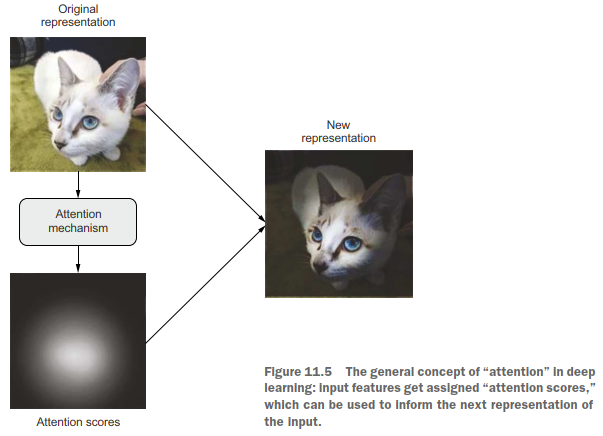

Crucially, this kind of attention mechanism can be used for more than just highlighting or erasing certain features. It can be used to make features context-aware. You’ve just learned about word embeddings—vector spaces that capture the “shape” of the semantic relationships between different words. In an embedding space, a single word has a fixed position—a fixed set of relationships with every other word in the space. But that’s not quite how language works: the meaning of a word is usually context-specific.

When you mark the date, you’re not talking about the same “date” as when you go on a date, nor is it the kind of date you’d buy at the market. When you say, “I’ll see you soon,” the meaning of the word “see” is subtly different from the “see” in “I’ll see this project to its end” or “I see what you mean.” And, of course, the meaning of pronouns like “he,” “it,” “in,” etc., is entirely sentence-specific and can even change multiple times within a single sentence. Clearly, a smart embedding space would provide a different vector representation
for a word depending on the other words surrounding it. That’s where self-attention comes in. The purpose of self-attention is to modulate the representation of a token by using the representations of related tokens in the sequence. This produces context-aware token representations. Consider an example sentence: “The train left the station on time.” Now, consider one word in the sentence: station. What kind of station are we talking about? Could it be a radio station? Maybe the International Space Station? Let’s figure it out algorithmically via self-attention.

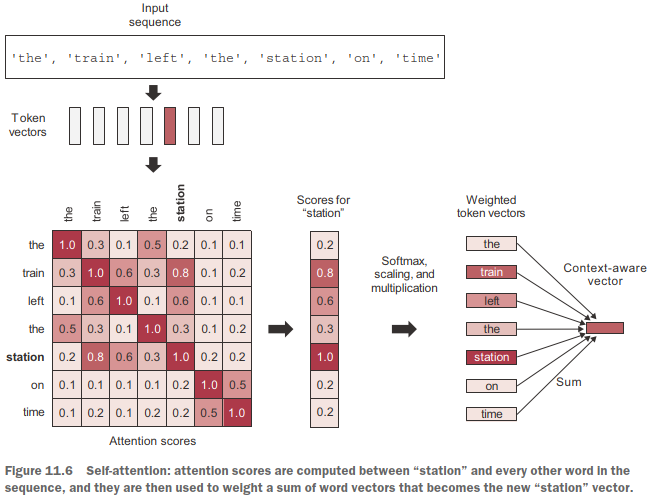

Step 1 is to compute relevancy scores between the vector for “station” and every other word in the sentence. These are our “attention scores.” We’re simply going to use the dot product between two word vectors as a measure of the strength of their relationship. It’s a very computationally efficient distance function, and it was already the standard way to relate two word embeddings to each other long before Transformers. In practice, these scores will also go through a scaling function and a softmax, but for now, that’s just an implementation detail.

Step 2 is to compute the sum of all word vectors in the sentence, weighted by our relevancy scores. Words closely related to “station” will contribute more to the sum (including the word “station” itself), while irrelevant words will contribute almost nothing. The resulting vector is our new representation for “station”: a representation that incorporates the surrounding context. In particular, it includes part of the “train” vector, clarifying that it is, in fact, a “train station.”

You’d repeat this process for every word in the sentence, producing a new
sequence of vectors encoding the sentence. Let’s see it in NumPy-like pseudocode:

### TODO 1

Implement scaled dot-product self-attention for each token:

1. Compute attention scores using $\alpha(\mathbf{q}, \mathbf{k}) = \langle \mathbf{q}, \mathbf{k} \rangle / \sqrt{d}$.
   1. Compute dot products between the pivot token vector and every token vector.
   2. Scale the scores by dividing by $\sqrt{d}$, where $d = input_sequence.shape[1]$.
   3. Apply softmax to obtain normalized attention weights.
2. Compute the output vector $\mathbf{o} = \sum_i a_i \mathbf{v}_i$.
   1. Use the attention weights (`scores`) to form the weighted sum of token vectors (`vectors`).

In [ ]:
def self_attention(input_sequence):
  output = np.zeros(shape=input_sequence.shape)
  for i, pivot_vector in enumerate(input_sequence):                       # Iterate over each token in the input sequence.
    scores = np.zeros(shape=(len(input_sequence),))
    for j, vector in enumerate(input_sequence):
      # TODO 1A
                              
    # TODO 1B
    
    # TODO 1C
    
    new_pivot_representation = np.zeros(shape=pivot_vector.shape)
    for j, vector in enumerate(input_sequence):
      # TODO 2A
      
    output[i] = new_pivot_representation
  ################
  return output                                                           # That sum is our output.

Of course, in practice you’d use a vectorized implementation. Keras has a built-in layer to handle it: the MultiHeadAttention layer. Here’s how you would use it:

### TODO 2

Create a Multi-Head Attention layer:

1. Define `num_heads = 4` and `embed_dim = 256`.
2. Initialize `mha_layer` using `layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)`.

[Reference](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention)

In [ ]:
# TODO


# outputs = mha_layer(inputs, inputs, inputs)                                   # We need to define the input for this line to work.

### TODO 2.1 (Concept Check)

- Why does the commented `mha_layer(inputs, inputs, inputs)` call pass the same tensor three times?

Answer: The commented line implements the self-attention with the same keys, queries, and values. Thus it needs the same inputs only. Now check the following section.

### Generalized Self-Attention: The query-key-value model

So far, we have only considered one input sequence. However, the Transformer architecture was originally developed for machine translation, where you have to deal with two input sequences: the source sequence you’re currently translating (such as “How’s the weather today?”), and the target sequence you’re converting it to (such as “¿Qué tiempo hace hoy?”). A Transformer is a sequence-to-sequence model: it was designed to convert one sequence into another. The self-attention mechanism as we’ve introduced it performs the following, schematically:

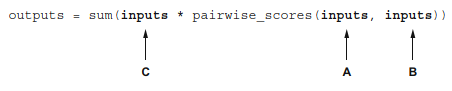

This means “for each token in inputs (A), compute how much the token is related to every token in inputs (B), and use these scores to weight a sum of tokens from inputs (C).” Crucially, there’s nothing that requires A, B, and C to refer to the same input sequence. In the general case, you could be doing this with three different sequences. We’ll call them “query,” “keys,” and “values.” The operation becomes “for each element in the query, compute how much the element is related to every key, and use these scores to weight a sum of values”:

image.png

This terminology comes from search engines and recommender systems. Imagine that you’re typing up a query to retrieve a photo from your collection—“dogs on the beach.” Internally, each of your pictures in the database is described by a set of keywords—“cat,” “dog,” “party,” etc. We’ll call those “keys.” The search engine will start by comparing your query to the keys in the database. “Dog” yields a match of 1, and “cat” yields a match of 0. It will then rank those keys by strength of match—relevance—and it will return the pictures associated with the top N matches, in order of relevance.

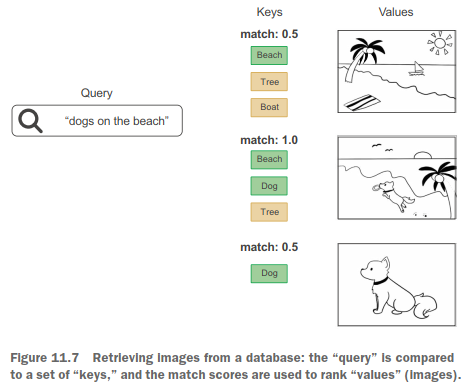

Conceptually, this is what Transformer-style attention is doing. You’ve got a reference sequence that describes something you’re looking for: the query. You’ve got a body of knowledge that you’re trying to extract information from: the values. Each value is assigned a key that describes the value in a format that can be readily compared to a query. You simply match the query to the keys. Then you return a weighted sum of values.

In practice, the keys and the values are often the same sequence. In machine translation, for instance, the query would be the target sequence, and the source sequence would play the roles of both keys and values: for each element of the target (like “tiempo”), you want to go back to the source (“How’s the weather today?”) and identify the different bits that are related to it (“tiempo” and “weather” should have a strong match). And naturally, if you’re just doing sequence classification, then query, keys, and values are all the same: you’re comparing a sequence to itself, to enrich each token with context from the whole sequence. That explains why we needed to pass inputs three times to our MultiHeadAttention layer. But why “multi-head” attention?

## Multi-head attention

“Multi-head attention” is an extra tweak to the self-attention mechanism, introduced in “Attention is all you need.” The “multi-head” moniker refers to the fact that the output space of the self-attention layer gets factored into a set of independent subspaces, learned separately: the initial query, key, and value are sent through three independent sets of dense projections, resulting in three separate vectors. Each vector is processed via neural attention, and the three outputs are concatenated back together into a single output sequence. Each such subspace is called a “head.” The full picture is shown below.


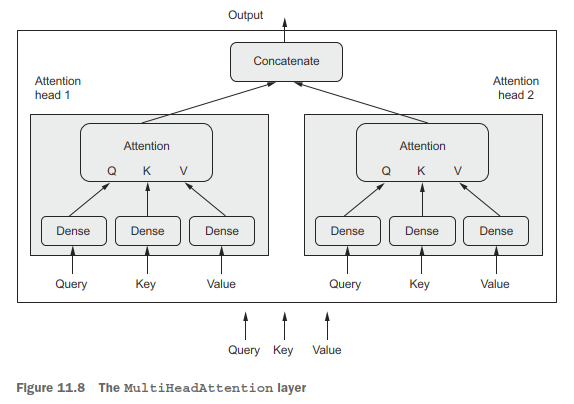

 ## The Transformer encoder

If adding extra dense projections is so useful, why don’t we also apply one or two to the output of the attention mechanism? Actually, that’s a great idea—let’s do that. And our model is starting to do a lot, so we might want to add residual connections to make sure we don’t destroy any valuable information. And there’s another thing: normalization layers are supposed to help gradients flow better during backpropagation. Let’s add those too.

That’s roughly the thought process that I imagine unfolded in the minds of the
inventors of the Transformer architecture at the time. Factoring outputs into multiple independent spaces, adding residual connections, adding normalization layers—all of these are standard architecture patterns that one would be wise to leverage in any complex model. Together, these bells and whistles form the Transformer encoder—one of two critical parts that make up the Transformer architecture.

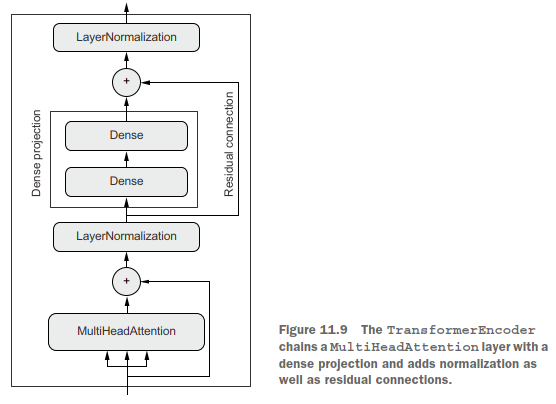

The original Transformer architecture consists of two parts: a Transformer encoder that processes the source sequence, and a Transformer decoder that uses the source sequence to generate a translated version.  

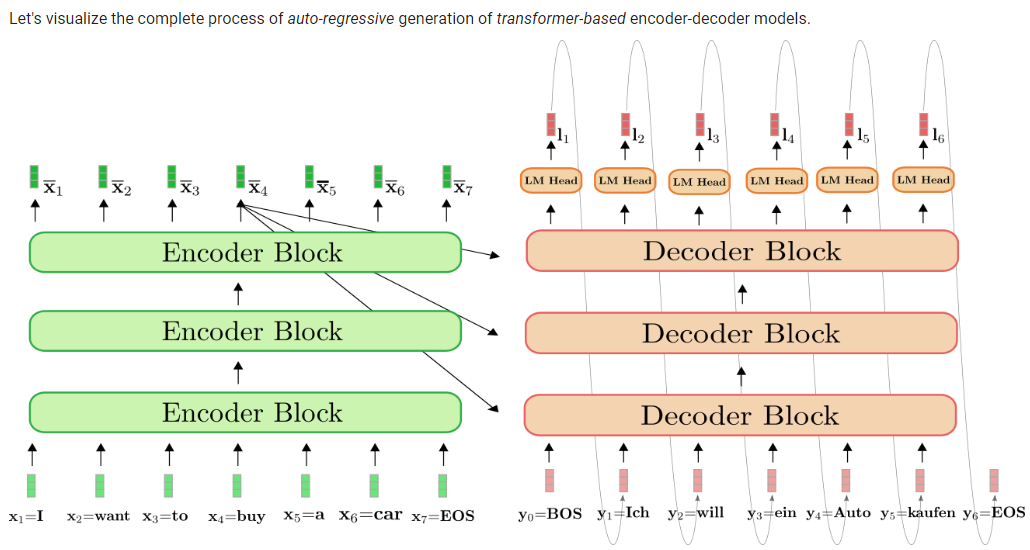

Crucially, the encoder part can be used for text classification—it’s a very generic module that ingests a sequence and learns to turn it into a more useful representation. Let’s implement a Transformer encoder and try it on the movie review sentiment
classification task.

## Using the Tranformer encoder on IMDB

Let us reuse the IMDB dataset from last week.

### TODO 3

1. Set `max_tokens = 20000`.
2. Set `max_len = 600`.
3. Load the IMDB dataset with:
   - `(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_tokens)`
4. Split training data into train/validation sets using indexing:
   - `x_train`: all but the last 5000 samples of `x_train_full`
   - `x_valid`: the last 5000 samples of `x_train_full`
   - `y_train`: all but the last 5000 samples of `y_train_full`
   - `y_valid`: the last 5000 samples of `y_train_full`
5. Print the shapes of `x_train`, `y_train`, `x_valid`, `y_valid`, `x_test`, and `y_test`.

[Reference](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data)

In [ ]:
# TODO


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: (20000,) (20000,), valid: (5000,) (5000,), test: (25000,) (25000,)


## Data Preparation

Run the following cell to prepare the data.

### TODO 4

Pad all review sequences to a fixed length:

1. Update `x_train` using `keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)`.
2. Update `x_valid` using `keras.preprocessing.sequence.pad_sequences(x_valid, maxlen=max_len)`.
3. Update `x_test` using `keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)`.

In [ ]:
#  TODO


## Build the Transformer Encoder

Run the following cell to create the Transformer encoder.

## TODO 5

Implement a custom `TransformerEncoder` layer.

1. Create a class `TransformerEncoder(layers.Layer)`.
2. In `__init__(self, embed_dim, dense_dim, num_heads, **kwargs)`:
   1. Call `super().__init__(**kwargs)`.
   2. Save `embed_dim`, `dense_dim`, and `num_heads` as instance attributes.
   3. Define `self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)`.
   4. Define `self.dense_proj` as a `keras.Sequential` stack with:
      - `layers.Dense(dense_dim, activation="relu")`
      - `layers.Dense(embed_dim)`
   5. Create two layer norms:
      - `self.layernorm_1 = layers.LayerNormalization()`
      - `self.layernorm_2 = layers.LayerNormalization()`
3. In `call(self, inputs, mask=None)`:
   1. If `mask` is provided, expand it to 3D with `mask = mask[:, tf.newaxis, :]`.
   2. Compute `attention_output` with `self.attention(inputs, inputs, attention_mask=mask)`.
   3. Compute `proj_input = self.layernorm_1(inputs + attention_output)`.
   4. Compute `proj_output = self.dense_proj(proj_input)`.
   5. Return `self.layernorm_2(proj_input + proj_output)`.
4. In `get_config(self)`:
   1. Start from `config = super().get_config()`.
   2. Add `embed_dim`, `num_heads`, and `dense_dim` via `config.update(...)`.
   3. Return `config`.
      

In [ ]:
# TODO



## Using the Transformer encoder for text classification

Now that we’ve implemented our TransformerEncoder, we can use it to assemble a
text-classification model.

Run the next cell to train the model using the Transformer encoder.

### TODO 6

Build and compile a Transformer-based text classifier.

1. Set model hyperparameters:
   - `vocab_size = 20000`
   - `embed_dim = 256`
   - `num_heads = 2`
   - `dense_dim = 32`
2. Define model input:
   - `inputs = keras.Input(shape=(None,), dtype="int64")`
3. Build the encoder stack:
   1. `x = layers.Embedding(vocab_size, embed_dim)(inputs)`
   2. `x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)`
4. Add classifier head:
   1. `x = layers.GlobalMaxPooling1D()(x)`
   2. `x = layers.Dropout(0.5)(x)`
   3. `outputs = layers.Dense(1, activation="sigmoid")(x)`
5. Create and compile the model:
   1. `model = keras.Model(inputs, outputs)`
   2. `model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])`
6. Print `model.summary()`. 

In [ ]:
# TODO

v

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 256)      │       543,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,664,033 (21.61 MB)

 Trainable params: 5,664,033 (21.61 MB)

 Non-trainable params: 0 (0.00 B)

Let’s train it.

### TODO 7

Train the model with checkpointing.

1. Create `callbacks` using `keras.callbacks.ModelCheckpoint` to save only the best model.
   - Save the checkpoint in `.keras` format.
2. Train the model and store the result in `history` using:
   - `x_train`, `y_train`
   - `validation_data=(x_valid, y_valid)`
   - `epochs=10`
   - `callbacks=callbacks`
3. Plot training curves using `plot_learning(history)`. 

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - accuracy: 0.6447 - loss: 0.6477 - val_accuracy: 0.8242 - val_loss: 0.3999
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.8253 - loss: 0.3899 - val_accuracy: 0.8568 - val_loss: 0.3321
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.8527 - loss: 0.3411 - val_accuracy: 0.8642 - val_loss: 0.3199
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 119ms/step - accuracy: 0.8658 - loss: 0.3204 - val_accuracy: 0.8722 - val_loss: 0.3114
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.8745 - loss: 0.2939 - val_accuracy: 0.8710 - val_loss: 0.3092
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.8866 - loss: 0.2694 - val_accuracy: 0.8772 - val_loss: 0.2971
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.8966 - loss: 0.2509 - val_accuracy: 0.8792 - val_loss: 0.2968
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.9064 - loss: 0

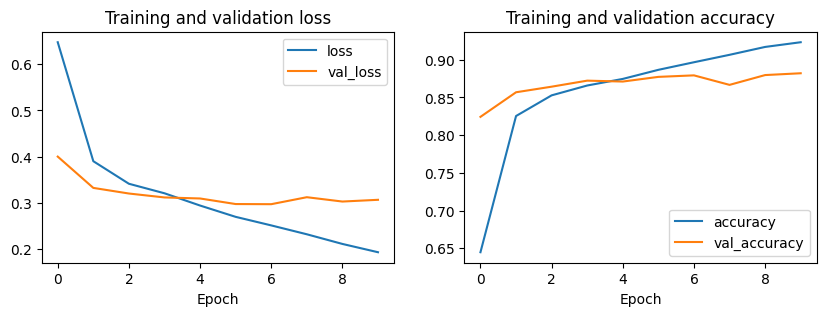

In [ ]:
# TODO


### TODO 8

1. Load the saved model into a variable named `model` using `keras.models.load_model(...)`.
   - Pass `custom_objects={"TransformerEncoder": TransformerEncoder}`.
2. Evaluate the model with `model.evaluate(x_test, y_test)` to obtain test loss and test accuracy.

In [ ]:
# TODO


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8698 - loss: 0.3065
Test acc: 0.870


It gets to 88% test accuracy.

At this point, you should start to feel a bit uneasy. Something’s off here. Can you tell what it is? I started off by highlighting the importance of word order. I said that Transformer was a sequence-processing architecture, originally developed for machine translation. And yet . . . the Transformer encoder you just saw in action wasn’t a sequence model at all. Did you
notice? It’s composed of dense layers that process sequence tokens independently
from each other, and an attention layer that looks at the tokens as a set. You could change the order of the tokens in a sequence, and you’d get the exact same pairwise attention scores and the exact same context-aware representations. If you were to completely scramble the words in every movie review, the model wouldn’t notice, and you’d still get the exact same accuracy. Self-attention is a set-processing mechanism, focused on the relationships between pairs of sequence elements—it’s blind to whether these elements occur at the beginning, at the end, or in the middle of a sequence. So why do we say that Transformer is a sequence model? And how could it possibly be good for machine translation if it doesn’t look at word order?

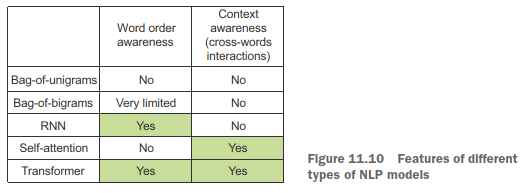

I hinted at the solution earlier: I mentioned in passing that Transformer was a hybrid approach that is technically order-agnostic, but that manually injects order information in the representations it processes. This is the missing ingredient! It’s called positional encoding. Let’s take a look.

## Using Positional Encoding to Re-inject Order Information

The idea behind positional encoding is very simple: to give the model access to word-order information, we’re going to add the word’s position in the sentence to each word embedding. Our input word embeddings will have two components: the usual word vector, which represents the word independently of any specific context, and a position vector, which represents the position of the word in the current sentence. Hopefully, the model will then figure out how to best leverage this additional information.

The simplest scheme you could come up with would be to concatenate the word’s
position to its embedding vector. You’d add a “position” axis to the vector and fill it with 0 for the first word in the sequence, 1 for the second, and so on.
That may not be ideal, however, because the positions can potentially be very large integers, which will disrupt the range of values in the embedding vector. As you know, neural networks don’t like very large input values, or discrete input distributions. The original “Attention is all you need” paper used an interesting trick to encode word positions: it added to the word embeddings a vector containing values in the range [-1, 1] that varied cyclically depending on the position (it used cosine functions to achieve this). This trick offers a way to uniquely characterize any integer in a large range via a vector of small values.

It’s clever, but it’s not what we’re going to use in our case. We’ll do something simpler and more effective: we’ll learn position-embedding vectors the same way we learn to embed word indices. We’ll then proceed to add our position embeddings to the corresponding word embeddings, to obtain a position-aware word embedding. This technique is called “positional embedding.”
Let’s implement it.

### TODO 9

Implement a custom `PositionalEmbedding` layer.

1. Create a class `PositionalEmbedding(layers.Layer)`.
2. In `__init__(self, sequence_length, input_dim, output_dim, **kwargs)`:
   1. Call `super().__init__(**kwargs)`.
   2. Define `self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim)`.
   3. Define `self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)`.
   4. Store `sequence_length`, `input_dim`, and `output_dim` as instance attributes.
3. In `call(self, inputs)`:
   1. Compute `length = tf.shape(inputs)[-1]`.
   2. Create positional indices with `positions = tf.range(start=0, limit=length, delta=1)`.
   3. Compute `embedded_tokens = self.token_embeddings(inputs)`.
   4. Compute `embedded_positions = self.position_embeddings(positions)`.
   5. Return `embedded_tokens + embedded_positions`.
4. In `compute_mask(self, inputs, mask=None)`:
   1. Return `tf.math.not_equal(inputs, 0)`.
5. In `get_config(self)`:
   1. Start from `config = super().get_config()`.
   2. Add `output_dim`, `sequence_length`, and `input_dim` via `config.update(...)`.
   3. Return `config`.
      

In [ ]:
# TODO



You would use this PositionEmbedding layer just like a regular Embedding layer. Let’s see it in action!

### Putting it all together: A text-classification Transformer

All you have to do to start taking word order into account is swap the old Embedding
layer with our position-aware version.

### TODO 10

Build a second classifier that includes positional information.

1. Start from the same architecture you built in **TODO 6**.
2. Define `sequence_length = 600`.
3. Replace the plain `Embedding` layer with your custom `PositionalEmbedding(sequence_length, vocab_size, embed_dim)` layer.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  5,273,600 │ input_layer_3[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 256) │    543,776 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        257 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,817,633 (22.19 MB)

 Trainable params: 5,817,633 (22.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 79ms/step - accuracy: 0.7455 - loss: 0.5266 - val_accuracy: 0.8572 - val_loss: 0.3197
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8697 - loss: 0.3095 - val_accuracy: 0.8782 - val_loss: 0.3000
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8971 - loss: 0.2511 - val_accuracy: 0.8866 - val_loss: 0.2653
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.9198 - loss: 0.2075 - val_accuracy: 0.8842 - val_loss: 0.2839
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9346 - loss: 0.1717 - val_accuracy: 0.8856 - val_loss: 0.2694
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9463 - loss: 0.1413 - val_accuracy: 0.8848 - val_loss: 0.2890
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9607 - loss: 0.1078 - val_accuracy: 0.8880 - val_loss: 0.3671
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9721 - loss: 0.0798 - 

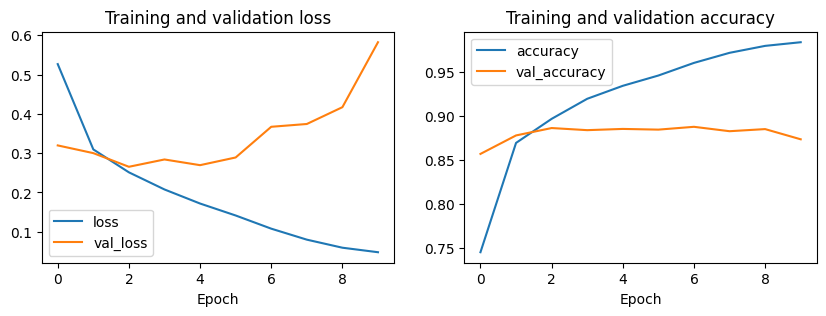

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# TODO


### TODO 11

1. Load the saved model into `model` using `keras.models.load_model(...)`.
   - Pass `custom_objects={"TransformerEncoder": TransformerEncoder, "PositionalEmbedding": PositionalEmbedding}`.
2. Evaluate with `model.evaluate(x_test, y_test)` and report test loss and test accuracy.

In [ ]:
# TODO



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8860 - loss: 0.2728
Test acc: 0.886


We get to 88.1% test accuracy, a solid improvement that clearly demonstrates the
value of word order information for text classification. This is our best sequence model so far! However, it’s still one notch below the bag-of-words approach.

### When to use sequence models over bag-of-words models?

You may sometimes hear that bag-of-words methods are outdated, and that Transformer-based sequence models are the way to go, no matter what task or dataset you’re looking at. This is definitely not the case: a small stack of Dense layers on top of a bag-of-bigrams remains a perfectly valid and relevant approach in many cases. In fact, among the various techniques that we’ve tried on the IMDB dataset, the best performing so far was the bag-of-bigrams!

It turns out that when approaching a new text-classification task, you should pay close attention to the ratio between the number of samples in your training data and the mean number of words per sample. If that ratio is small—less than 1,500—then the bag-of-bigrams model will perform better (and as a bonus, it will be much faster to train and to iterate on too). If that ratio is higher than 1,500, then you should go with a sequence model. In other words, sequence models work best when lots of training data is available and when each sample is relatively short.

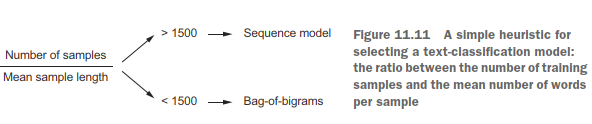

So if you’re classifying 1,000-word long documents, and you have 100,000 of them (a ratio of 100), you should go with a bigram model. If you’re classifying tweets that are 40 words long on average, and you have 50,000 of them (a ratio of 1,250), you should also go with a bigram model. But if you increase your dataset size to 500,000 tweets (a ratio of 12,500), go with a Transformer encoder. What about the IMDB movie review classification task? We had 20,000 training samples and an average word count of 233, so our rule of thumb points toward a bigram model, which confirms what we found in practice.

This intuitively makes sense: the input of a sequence model represents a richer
and more complex space, and thus it takes more data to map out that space; mean-
while, a plain set of terms is a space so simple that you can train a logistic regression on top using just a few hundreds or thousands of samples. In addition, the shorter a sample is, the less the model can afford to discard any of the information it contains— in particular, word order becomes more important, and discarding it can create ambiguity. The sentences “this movie is the bomb” and “this movie was a bomb” have very close unigram representations, which could confuse a bag-of-words model, but a sequence model could tell which one is negative and which one is positive. With a longer sample, word statistics would become more reliable and the topic or sentiment would be more apparent from the word histogram alone.